In [9]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, matthews_corrcoef, f1_score, roc_curve
)
import tensorflow as tf
import csv


# --- GPU Setup: Memory Growth Enabled ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"[INFO] {len(gpus)} GPU(s) available. Memory growth enabled.")
    except RuntimeError as e:
        print(f"[ERROR] {e}")
else:
    print("[INFO] No GPU found, running on CPU.")


# --- Data Loading ---
def import_data(csv_file):
    df = pd.read_csv(csv_file)
    patient_ids = df.iloc[:, 0]
    features = df.iloc[:, 1:316]  # Adjust columns as needed
    feats = []
    unique_ids = patient_ids.unique()
    for pid in unique_ids:
        patient_data = features[patient_ids == pid].values
        feats.append(patient_data.tolist())
    return feats


def import_labels(csv_file, label_column_name):
    df = pd.read_csv(csv_file)
    patient_ids = df.iloc[:, 0]
    labels_df = df[[patient_ids.name, label_column_name]].drop_duplicates(subset=patient_ids.name)
    labels_df = labels_df.set_index(patient_ids.name)
    unique_ids = patient_ids.unique()
    labels = labels_df.loc[unique_ids][label_column_name].values
    return labels.astype(np.int32)


# --- Feature Standardization ---
def standardize_features(feats, mean=None, std=None):
    if mean is None or std is None:
        mean_record = []
        std_record = []
        for case in feats:
            case_arr = np.asarray(case)
            mean_record.append(np.mean(case_arr, axis=0))
            std_record.append(np.std(case_arr, axis=0))
        mean = np.nanmean(mean_record, axis=0)
        std = np.nanstd(std_record, axis=0)
        
        # Fix: prevent division by zero
        std[std == 0] = 1.0  # or use epsilon threshold as above

        std = np.nan_to_num(std)
        mean[np.isinf(mean)] = 0

    standardized_feats = []
    for patient in feats:
        patient = np.array(patient)
        patient -= mean
        patient /= std
        patient = np.nan_to_num(patient)
        standardized_feats.append(patient)
    return standardized_feats, mean, std



# --- Balanced Random Batcher ---
def balanced_random_batcher(feats, time_step, batch_size, labels, rng):
    num_features = len(feats[0][0])

    class0_idx = [i for i, lbl in enumerate(labels) if lbl == 0]
    class1_idx = [i for i, lbl in enumerate(labels) if lbl == 1]

    half_batch = batch_size // 2
    batched_data = np.zeros((batch_size, time_step, num_features))
    batched_labels = np.zeros((batch_size, 2))

    # Sample half batch from class 0
    for i in range(half_batch):
        idx = rng.choice(class0_idx)
        case = np.array(feats[idx])
        label = labels[idx]
        batched_labels[i, label] = 1
        for j in range(time_step):
            sample_idx = rng.choice(len(case))
            batched_data[i, j, :] = case[sample_idx]

    # Sample half batch from class 1
    for i in range(half_batch, batch_size):
        idx = rng.choice(class1_idx)
        case = np.array(feats[idx])
        label = labels[idx]
        batched_labels[i, label] = 1
        for j in range(time_step):
            sample_idx = rng.choice(len(case))
            batched_data[i, j, :] = case[sample_idx]

    # Handle odd batch size
    if batch_size % 2 == 1:
        idx = rng.choice(class0_idx + class1_idx)
        case = np.array(feats[idx])
        label = labels[idx]
        batched_labels[-1, label] = 1
        for j in range(time_step):
            sample_idx = rng.choice(len(case))
            batched_data[-1, j, :] = case[sample_idx]

    return batched_data, batched_labels


# --- Full sequence batch generation with circular sampling (no zero padding) ---
def generate_full_sequence_batch(feats, time_step):
    batch_x = []
    for patient in feats:
        patient = np.array(patient)
        if len(patient) >= time_step:
            indices = np.linspace(0, len(patient) - 1, time_step, dtype=int)
            seq = patient[indices]
        else:
            repeats = (time_step // len(patient)) + 1
            extended_seq = np.tile(patient, (repeats, 1))
            seq = extended_seq[:time_step]
        batch_x.append(seq)
    return np.array(batch_x)


# --- Build Keras RNN Model ---
def build_model(num_input, seq_len, num_classes, drop_rate):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(seq_len, num_input)),
        tf.keras.layers.Masking(mask_value=0.0),  # Safety mask
        tf.keras.layers.Dense(num_input, activation=tf.nn.leaky_relu),
        tf.keras.layers.LSTM(75, return_sequences=True),
        tf.keras.layers.Dropout(drop_rate),
        tf.keras.layers.LSTM(25),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


[INFO] 1 GPU(s) available. Memory growth enabled.


In [10]:
def run_kfold_training(
    csv_file,
    label_column,
    seq_len=50,
    drop=0.3,
    num_classes=2,
    training_steps=200,
    batch_size=32,
    save_interval=50,
    learning_rate=0.001,
    output_root="output_seq_50_v2",
    seed=None
):
    # Set random seeds consistently using numpy Generator for reproducibility
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    raw_features = import_data(csv_file)
    all_labels = np.array(import_labels(csv_file, label_column))

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    all_true = []
    all_pred = []
    all_probas = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(raw_features, all_labels)):
        print(f"\n[INFO] Starting Fold {fold + 1}/10")

        raw_train_feats = [raw_features[i] for i in train_idx]
        raw_test_feats = [raw_features[i] for i in test_idx]
        train_lbls = all_labels[train_idx]
        test_lbls = all_labels[test_idx]

        train_feats, train_mean, train_std = standardize_features(raw_train_feats)
        test_feats, _, _ = standardize_features(raw_test_feats, train_mean, train_std)

        num_input = len(train_feats[0][0])
        model = build_model(num_input, seq_len, num_classes, drop)

        fold_dir = os.path.join(output_root, f"fold_{fold + 1}")
        os.makedirs(fold_dir, exist_ok=True)

        metrics_file = os.path.join(fold_dir, "metrics.csv")
        with open(metrics_file, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["step", "accuracy", "precision", "recall", "specificity", "auc", "mcc", "loss"])

        loss_history = []

        for step in range(training_steps + 1):
            batch_x, batch_y = balanced_random_batcher(train_feats, seq_len, batch_size, train_lbls, rng)
            loss, acc = model.train_on_batch(batch_x, batch_y)
            loss_history.append(loss)

            if step % save_interval == 0 or step == training_steps:
                val_x = generate_full_sequence_batch(test_feats, seq_len)
                val_y = tf.keras.utils.to_categorical(test_lbls, num_classes=num_classes)
                preds_val = model.predict(val_x, verbose=0)
                y_true = np.argmax(val_y, axis=1)
                y_pred = np.argmax(preds_val, axis=1)
                probas = preds_val[:, 1]

                acc = np.mean(y_true == y_pred)
                prec = precision_score(y_true, y_pred, zero_division=0)
                rec = recall_score(y_true, y_pred, zero_division=0)
                spec = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
                try:
                    auc_val = roc_auc_score(y_true, probas)
                except ValueError:
                    auc_val = float('nan')
                mcc = matthews_corrcoef(y_true, y_pred)

                print(f"[Fold {fold + 1} | Step {step}] Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, Spec: {spec:.4f}, AUC: {auc_val:.4f}, MCC: {mcc:.4f}, Loss: {loss:.4f}")

                with open(metrics_file, "a", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow([step, acc, prec, rec, spec, auc_val, mcc, loss])

                plt.figure(figsize=(6, 5))
                plt.plot(range(len(loss_history)), loss_history, label="Training Loss", color="orange")

                ax = plt.gca()
                ax.set_facecolor("white")

                # X label with white background
                plt.xlabel(
                    "Training Step",
                    fontsize=12,
                    fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.4')
                )

                # Y label with white background
                plt.ylabel(
                    "Loss",
                    fontsize=12,
                    fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.4')
                )

                # Title with white background
                plt.title(
                    f"Fold {fold + 1} - Loss up to Step {step}",
                    fontsize=14,
                    fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5')
                )

                # Make ticks labels more readable by setting their background to white via tick_params and custom tick labels
                plt.xticks(fontsize=10, fontweight='bold', color='black')
                plt.yticks(fontsize=10, fontweight='bold', color='black')

                plt.legend()

                loss_plot_path = os.path.join(fold_dir, f"loss_up_to_step_{step}.png")
                plt.savefig(loss_plot_path)
                plt.close()

        # Final fold evaluation: collect predictions for overall stats later
        full_val_x = generate_full_sequence_batch(test_feats, seq_len)
        full_val_y = tf.keras.utils.to_categorical(test_lbls, num_classes=num_classes)
        preds_full = model.predict(full_val_x, verbose=0)
        all_true.extend(np.argmax(full_val_y, axis=1).tolist())
        all_pred.extend(np.argmax(preds_full, axis=1).tolist())
        all_probas.extend(preds_full[:, 1].tolist())

    # --- Overall Metrics and Plots after all folds ---
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_probas = np.array(all_probas)
    
    # Save true labels, predicted labels, and predicted probabilities as CSV
    results_csv_path = os.path.join(output_root, "all_predictions.csv")
    with open(results_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["true_label", "predicted_label", "predicted_probability"])
        for t, p, prob in zip(all_true, all_pred, all_probas):
            writer.writerow([t, p, prob])

    overall_cm = confusion_matrix(all_true, all_pred)
    overall_class_report = classification_report(all_true, all_pred, zero_division=0, digits = 4)

    # Clean NaN or Inf values from probabilities and corresponding true labels
    valid_mask = np.isfinite(all_probas)
    all_probas_clean = all_probas[valid_mask]
    all_true_clean = all_true[valid_mask]

    # Compute AUC only if both classes are present
    if len(all_true_clean) > 0 and len(np.unique(all_true_clean)) > 1:
        overall_auc = roc_auc_score(all_true_clean, all_probas_clean)
    else:
        overall_auc = float('nan')  # Not enough valid data to compute AUC

    overall_specificity = recall_score(all_true, all_pred, pos_label=0, zero_division=0)
    overall_mcc = matthews_corrcoef(all_true, all_pred)

    summary = (
        f"=== Overall Classification Report ===\n{overall_class_report}\n\n"
        f"Confusion Matrix:\n{overall_cm}\n\n"
        f"AUC: {overall_auc:.4f}\n"
        f"Specificity: {overall_specificity:.4f}\n"
        f"MCC: {overall_mcc:.4f}\n"
    )

    print("\n[INFO] === Overall metrics across all folds ===")
    print(summary)

    # Save the summary metrics to a text file
    os.makedirs(output_root, exist_ok=True)
    metrics_txt_path = os.path.join(output_root, "overall_metrics.txt")
    with open(metrics_txt_path, "w") as f:
        f.write(summary)

    # Plot confusion matrix with improved labels and formatting
    plt.figure(figsize=(7, 6))
    class_names = ['Class 0(Healthy)', 'Class1(Sick)']  # Update this list if your class names differ

    cmap = sns.light_palette("navy", as_cmap=True)
    ax = sns.heatmap(overall_cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                     annot_kws={"weight": "bold", "size": 18},
                     xticklabels=class_names, yticklabels=class_names)

    for text in ax.texts:
        val = int(text.get_text())
        norm_val = val / overall_cm.max() if overall_cm.max() > 0 else 0
        rgb = ax.collections[0].get_cmap()(norm_val)[:3]
        luminance = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
        text_color = "white" if luminance < 0.5 else "black"
        text.set_color(text_color)

    plt.xlabel("Predicted Label", fontsize=16, fontweight='bold')
    plt.ylabel("True Label", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title("Confusion Matrix", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_root, "overall_confusion_matrix.png"))
    plt.show()

    # Plot ROC curve only if valid data available and both classes present
    if len(all_true_clean) > 0 and len(np.unique(all_true_clean)) > 1:
        fpr, tpr, _ = roc_curve(all_true_clean, all_probas_clean)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {overall_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=14)
        plt.ylabel('True Positive Rate', fontsize=14)
        plt.title('ROC Curve', fontsize=16, fontweight='bold')
        plt.legend(loc="lower right", fontsize=12)
        plt.tight_layout()
        plt.savefig(os.path.join(output_root, "overall_roc_curve.png"))
        plt.show()
    else:
        print("[WARN] Not enough valid data to plot ROC curve.")



[INFO] Starting Fold 1/10
[Fold 1 | Step 0] Acc: 0.7778, Prec: 0.6667, Rec: 1.0000, Spec: 0.6000, AUC: 0.7500, MCC: 0.6325, Loss: 0.7833
[Fold 1 | Step 50] Acc: 1.0000, Prec: 1.0000, Rec: 1.0000, Spec: 1.0000, AUC: 1.0000, MCC: 1.0000, Loss: 0.4989
[Fold 1 | Step 100] Acc: 0.7778, Prec: 0.6667, Rec: 1.0000, Spec: 0.6000, AUC: 0.8000, MCC: 0.6325, Loss: 0.1559
[Fold 1 | Step 150] Acc: 0.7778, Prec: 0.6667, Rec: 1.0000, Spec: 0.6000, AUC: 1.0000, MCC: 0.6325, Loss: 0.3055
[Fold 1 | Step 200] Acc: 0.7778, Prec: 0.6667, Rec: 1.0000, Spec: 0.6000, AUC: 0.9000, MCC: 0.6325, Loss: 0.2708

[INFO] Starting Fold 2/10
[Fold 2 | Step 0] Acc: 0.6667, Prec: 1.0000, Rec: 0.2500, Spec: 1.0000, AUC: 0.8500, MCC: 0.3953, Loss: 0.7478
[Fold 2 | Step 50] Acc: 0.6667, Prec: 0.6667, Rec: 0.5000, Spec: 0.8000, AUC: 0.7500, MCC: 0.3162, Loss: 0.2490
[Fold 2 | Step 100] Acc: 0.8889, Prec: 0.8000, Rec: 1.0000, Spec: 0.8000, AUC: 0.9000, MCC: 0.8000, Loss: 0.2917
[Fold 2 | Step 150] Acc: 0.7778, Prec: 0.7500, R

/apps/tensorflow/2.4.1.cuda11/lib/python3.8/site-packages/sklearn/metrics/_classification.py:870: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


[Fold 6 | Step 0] Acc: 0.5556, Prec: 0.5556, Rec: 1.0000, Spec: 0.0000, AUC: 0.6500, MCC: 0.0000, Loss: 0.6902


/apps/tensorflow/2.4.1.cuda11/lib/python3.8/site-packages/sklearn/metrics/_classification.py:870: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


[Fold 6 | Step 50] Acc: 0.5556, Prec: 0.5556, Rec: 1.0000, Spec: 0.0000, AUC: 0.6000, MCC: 0.0000, Loss: 0.5222
[Fold 6 | Step 100] Acc: 0.6667, Prec: 0.7500, Rec: 0.6000, Spec: 0.7500, AUC: 0.8500, MCC: 0.3500, Loss: 0.3892
[Fold 6 | Step 150] Acc: 0.5556, Prec: 0.6000, Rec: 0.6000, Spec: 0.5000, AUC: 0.7500, MCC: 0.1000, Loss: 0.1217
[Fold 6 | Step 200] Acc: 0.6667, Prec: 0.6667, Rec: 0.8000, Spec: 0.5000, AUC: 0.8000, MCC: 0.3162, Loss: 0.3093

[INFO] Starting Fold 7/10
[Fold 7 | Step 0] Acc: 0.6250, Prec: 0.6667, Rec: 0.5000, Spec: 0.7500, AUC: 0.7500, MCC: 0.2582, Loss: 0.7889
[Fold 7 | Step 50] Acc: 0.8750, Prec: 1.0000, Rec: 0.7500, Spec: 1.0000, AUC: 0.8125, MCC: 0.7746, Loss: 0.5658
[Fold 7 | Step 100] Acc: 0.6250, Prec: 1.0000, Rec: 0.2500, Spec: 1.0000, AUC: 1.0000, MCC: 0.3780, Loss: 0.5847
[Fold 7 | Step 150] Acc: 0.8750, Prec: 0.8000, Rec: 1.0000, Spec: 0.7500, AUC: 0.8750, MCC: 0.7746, Loss: 0.0818
[Fold 7 | Step 200] Acc: 0.6250, Prec: 0.5714, Rec: 1.0000, Spec: 0.2500,

/apps/tensorflow/2.4.1.cuda11/lib/python3.8/site-packages/sklearn/metrics/_classification.py:870: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


[Fold 9 | Step 0] Acc: 0.5000, Prec: 0.0000, Rec: 0.0000, Spec: 1.0000, AUC: 0.3125, MCC: 0.0000, Loss: 0.6909
[Fold 9 | Step 50] Acc: 0.7500, Prec: 1.0000, Rec: 0.5000, Spec: 1.0000, AUC: 0.7500, MCC: 0.5774, Loss: 0.4389
[Fold 9 | Step 100] Acc: 0.6250, Prec: 1.0000, Rec: 0.2500, Spec: 1.0000, AUC: 0.6875, MCC: 0.3780, Loss: 0.1926


/apps/tensorflow/2.4.1.cuda11/lib/python3.8/site-packages/sklearn/metrics/_classification.py:870: RuntimeWarning: invalid value encountered in double_scalars
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


[Fold 9 | Step 150] Acc: 0.5000, Prec: 0.0000, Rec: 0.0000, Spec: 1.0000, AUC: 0.9375, MCC: 0.0000, Loss: 0.0735
[Fold 9 | Step 200] Acc: 0.6250, Prec: 1.0000, Rec: 0.2500, Spec: 1.0000, AUC: 0.7500, MCC: 0.3780, Loss: 0.2424

[INFO] Starting Fold 10/10
[Fold 10 | Step 0] Acc: 0.2500, Prec: 0.3333, Rec: 0.5000, Spec: 0.0000, AUC: 0.3750, MCC: -0.5774, Loss: 0.7953
[Fold 10 | Step 50] Acc: 0.5000, Prec: 0.5000, Rec: 0.2500, Spec: 0.7500, AUC: 0.4375, MCC: 0.0000, Loss: 0.2985
[Fold 10 | Step 100] Acc: 0.5000, Prec: 0.5000, Rec: 0.7500, Spec: 0.2500, AUC: 0.5000, MCC: 0.0000, Loss: 0.5832
[Fold 10 | Step 150] Acc: 0.7500, Prec: 0.7500, Rec: 0.7500, Spec: 0.7500, AUC: 0.7500, MCC: 0.5000, Loss: 0.0718
[Fold 10 | Step 200] Acc: 0.6250, Prec: 0.6000, Rec: 0.7500, Spec: 0.5000, AUC: 0.6875, MCC: 0.2582, Loss: 0.1298

[INFO] === Overall metrics across all folds ===
=== Overall Classification Report ===
              precision    recall  f1-score   support

           0     0.6923    0.6000   

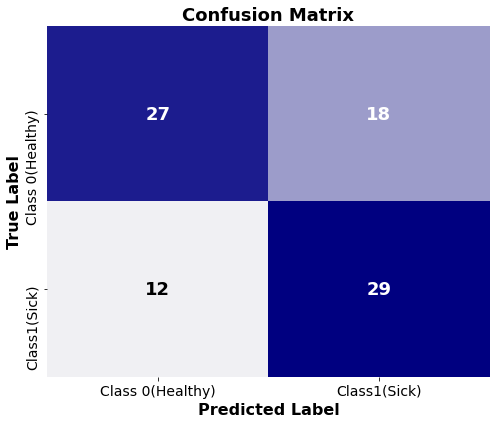

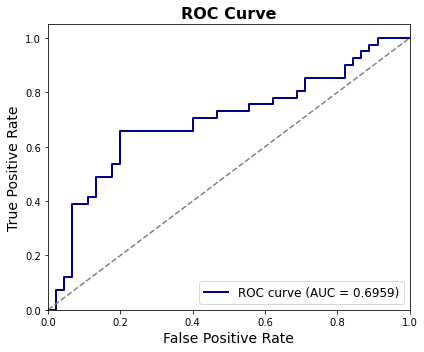

In [11]:
csv_file = "/blue/pinaki.sarder/narra.sr/5_DN_SKorea/data/combined_glom_features_with_outcomes.csv"
label_column = "3y_composite_outcome"
output_root = "v3_output_seq_30_drop_0.4_lr_0.002_seed_62"
seed = 42
run_kfold_training(
        csv_file=csv_file,
        label_column=label_column,
        seq_len=30,
        drop=0.4,
        num_classes=2,
        training_steps=200,
        batch_size=8,
        save_interval=50,
        learning_rate=0.002,
        output_root=output_root,
        seed=seed
    )